In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OrdinalEncoder,LabelEncoder
from sklearn.model_selection import train_test_split

In [5]:
df=pd.read_csv("netflix_customer_churn.csv")

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             5000 non-null   object 
 1   age                     5000 non-null   int64  
 2   gender                  5000 non-null   object 
 3   subscription_type       5000 non-null   object 
 4   watch_hours             5000 non-null   float64
 5   last_login_days         5000 non-null   int64  
 6   region                  5000 non-null   object 
 7   device                  5000 non-null   object 
 8   monthly_fee             5000 non-null   float64
 9   churned                 5000 non-null   int64  
 10  payment_method          5000 non-null   object 
 11  number_of_profiles      5000 non-null   int64  
 12  avg_watch_time_per_day  5000 non-null   float64
 13  favorite_genre          5000 non-null   object 
dtypes: float64(3), int64(4), object(7)
memor

In [7]:
df.head()

,customer_id,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,a9b75100-82a8-427a-a208-72f24052884a,51,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action
1,49a5dfd9-7e69-4022-a6ad-0a1b9767fb5b,47,Other,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi
2,4d71f6ce-fca9-4ff7-8afa-197ac24de14b,27,Female,Standard,16.32,10,Asia,TV,13.99,0,Crypto,2,1.48,Drama
3,d3c72c38-631b-4f9e-8a0e-de103cad1a7d,53,Other,Premium,4.51,12,Oceania,TV,17.99,1,Crypto,2,0.35,Horror
4,4e265c34-103a-4dbb-9553-76c9aa47e946,56,Other,Standard,1.89,13,Africa,Mobile,13.99,1,Crypto,2,0.13,Action


In [8]:
df["region"].unique()

array(['Africa', 'Europe', 'Asia', 'Oceania', 'South America',
       'North America'], dtype=object)

In [9]:
df["device"].unique()

array(['TV', 'Mobile', 'Laptop', 'Desktop', 'Tablet'], dtype=object)

In [10]:
df["payment_method"].unique()

array(['Gift Card', 'Crypto', 'Debit Card', 'PayPal', 'Credit Card'],
      dtype=object)

In [11]:
df["favorite_genre"].unique()

array(['Action', 'Sci-Fi', 'Drama', 'Horror', 'Romance', 'Comedy',
       'Documentary'], dtype=object)

In [12]:
df.drop("customer_id",inplace=True,axis=1)

In [13]:
import math
def plot_all_hists(df):
    numeric_cols=df.select_dtypes(include=[np.number]).columns
    num_cols=3
    num_rows=math.ceil(len(numeric_cols)/num_cols)

    plt.figure(figsize=(5 * num_cols , 4 * num_rows))

    for i, col in enumerate(numeric_cols, 1):
        plt.subplot(num_rows,num_cols,i)
        sns.histplot(df[col],kde=True,bins=30)

    plt.tight_layout()
    plt.show()

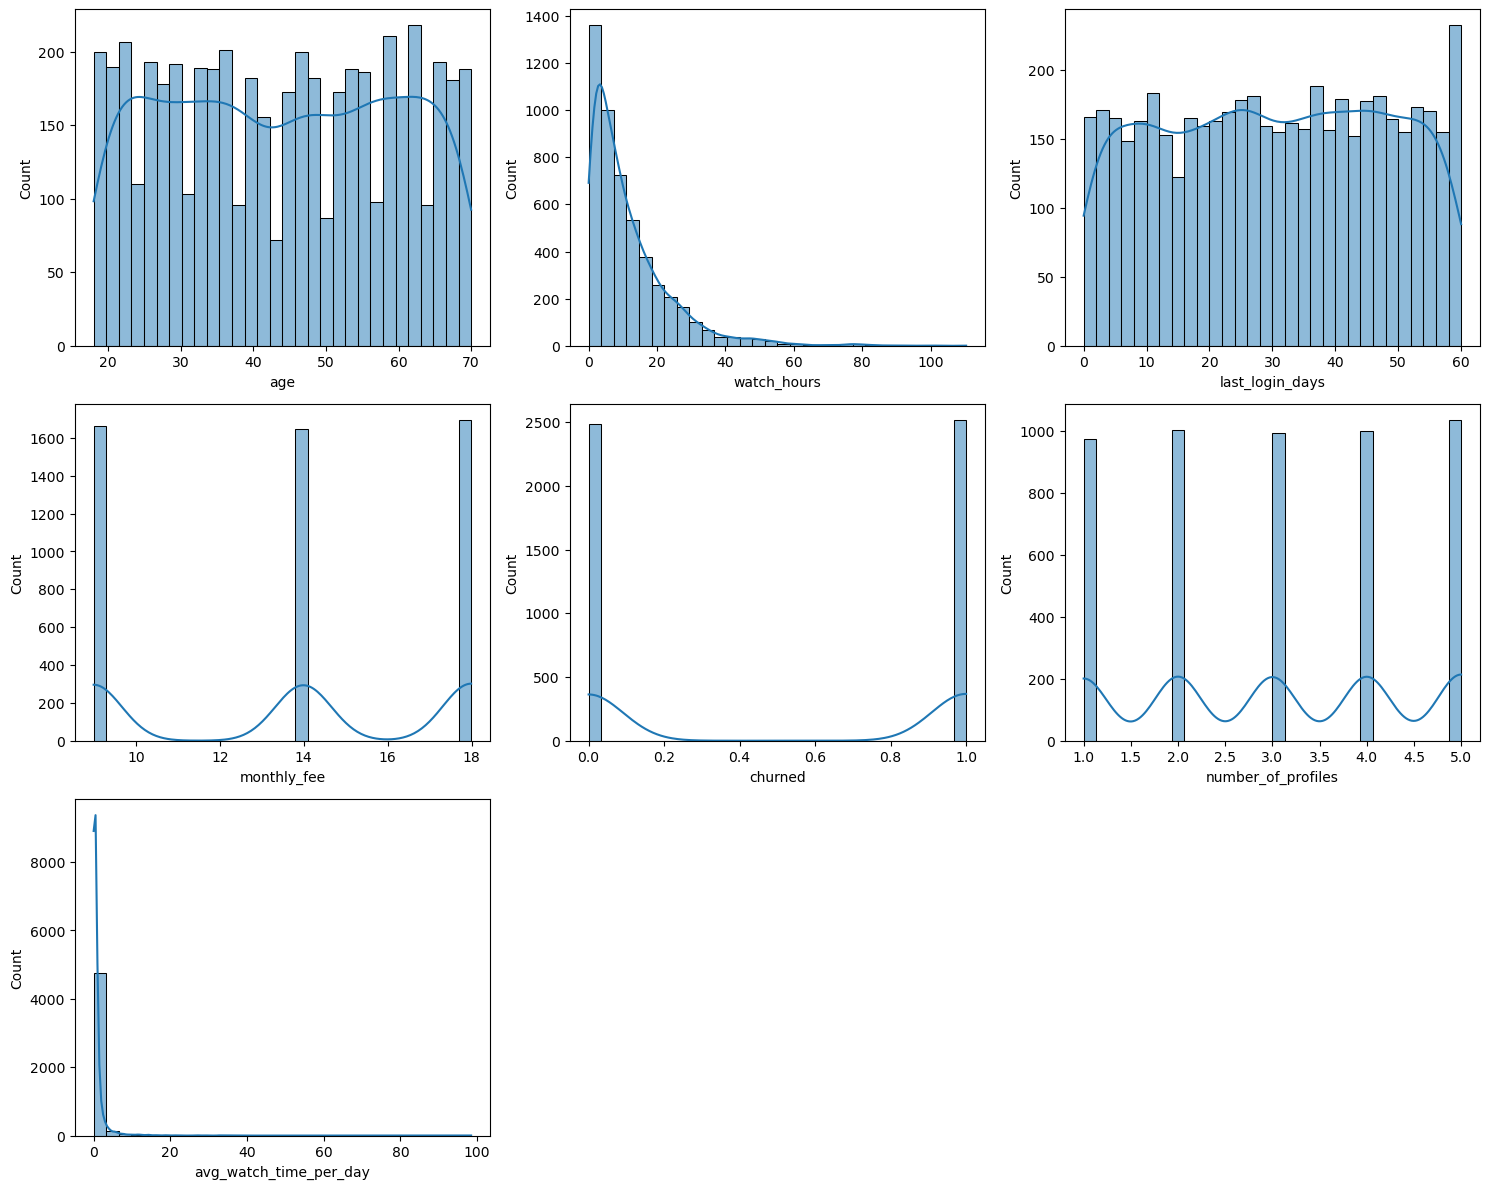

In [14]:
plot_all_hists(df)

In [15]:
df.head()

,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,51,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action
1,47,Other,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi
2,27,Female,Standard,16.32,10,Asia,TV,13.99,0,Crypto,2,1.48,Drama
3,53,Other,Premium,4.51,12,Oceania,TV,17.99,1,Crypto,2,0.35,Horror
4,56,Other,Standard,1.89,13,Africa,Mobile,13.99,1,Crypto,2,0.13,Action


In [16]:
X=df.drop("churned",axis=1)
y=df["churned"]

In [17]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [18]:
X_train["subscription_type"].unique()

array(['Standard', 'Basic', 'Premium'], dtype=object)

In [19]:
subs_class=["Basic","Standard","Premium"]
ordinal=OrdinalEncoder(categories=[subs_class])
X_train["subscription_type_encoded"]=ordinal.fit_transform(X_train[["subscription_type"]])
X_test["subscription_type_encoded"]=ordinal.transform(X_test[["subscription_type"]])

In [20]:
X_train.head()

,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre,subscription_type_encoded
4884,54,Other,Standard,0.72,0,Europe,Laptop,13.99,Gift Card,5,0.72,Horror,1.0
3163,18,Female,Standard,2.26,48,Africa,Desktop,13.99,PayPal,1,0.05,Action,1.0
490,32,Male,Basic,3.87,32,South America,TV,8.99,Credit Card,2,0.12,Drama,0.0
862,54,Male,Standard,3.47,31,Europe,Laptop,13.99,Crypto,5,0.11,Sci-Fi,1.0
1740,63,Other,Premium,13.82,38,North America,Desktop,17.99,Crypto,2,0.35,Sci-Fi,2.0


In [21]:
X_train.columns

Index(['age', 'gender', 'subscription_type', 'watch_hours', 'last_login_days',
       'region', 'device', 'monthly_fee', 'payment_method',
       'number_of_profiles', 'avg_watch_time_per_day', 'favorite_genre',
       'subscription_type_encoded'],
      dtype='object')

In [22]:
le_gender=LabelEncoder()
le_region=LabelEncoder()
le_payment=LabelEncoder()
le_genre=LabelEncoder()

X_train["gender_encoded"]=le_gender.fit_transform(X_train["gender"])
X_train["region_encoded"]=le_region.fit_transform(X_train["region"])
X_train["payment_method_encoded"]=le_payment.fit_transform(X_train["payment_method"])
X_train["favourite_genre_encoded"]=le_genre.fit_transform(X_train["favorite_genre"])

X_test["gender_encoded"]=le_gender.transform(X_test["gender"])
X_test["region_encoded"]=le_region.transform(X_test["region"])
X_test["payment_method_encoded"]=le_payment.transform(X_test["payment_method"])
X_test["favourite_genre_encoded"]=le_genre.transform(X_test["favorite_genre"])

In [23]:
X_train["favorite_genre"].value_counts()

favorite_genre
Romance        548
Drama          547
Sci-Fi         542
Horror         539
Documentary    539
Comedy         521
Action         514
Name: count, dtype: int64

In [24]:
X_test.head()

,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre,subscription_type_encoded,gender_encoded,region_encoded,payment_method_encoded,favourite_genre_encoded
1501,39,Other,Basic,9.96,22,South America,Tablet,8.99,Gift Card,5,0.43,Drama,0.0,2,5,3,3
2586,18,Female,Standard,0.25,37,Africa,Laptop,13.99,Debit Card,5,0.01,Sci-Fi,1.0,0,0,2,6
2653,19,Female,Standard,8.54,6,Africa,TV,13.99,Credit Card,3,1.22,Romance,1.0,0,0,0,5
1055,34,Male,Premium,13.49,51,South America,Tablet,17.99,Debit Card,1,0.26,Horror,2.0,1,5,2,4
705,29,Male,Basic,24.18,59,Africa,Laptop,8.99,Credit Card,1,0.40,Documentary,0.0,1,0,0,2


In [25]:
X_train.head()

,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre,subscription_type_encoded,gender_encoded,region_encoded,payment_method_encoded,favourite_genre_encoded
4884,54,Other,Standard,0.72,0,Europe,Laptop,13.99,Gift Card,5,0.72,Horror,1.0,2,2,3,4
3163,18,Female,Standard,2.26,48,Africa,Desktop,13.99,PayPal,1,0.05,Action,1.0,0,0,4,0
490,32,Male,Basic,3.87,32,South America,TV,8.99,Credit Card,2,0.12,Drama,0.0,1,5,0,3
862,54,Male,Standard,3.47,31,Europe,Laptop,13.99,Crypto,5,0.11,Sci-Fi,1.0,1,2,1,6
1740,63,Other,Premium,13.82,38,North America,Desktop,17.99,Crypto,2,0.35,Sci-Fi,2.0,2,3,1,6


In [26]:
X_train.drop(["gender","subscription_type","region","device","payment_method","favorite_genre"],axis=1,inplace=True)
X_test.drop(["gender","subscription_type","region","device","payment_method","favorite_genre"],axis=1,inplace=True)

In [27]:
X_train.head()

,age,watch_hours,last_login_days,monthly_fee,number_of_profiles,avg_watch_time_per_day,subscription_type_encoded,gender_encoded,region_encoded,payment_method_encoded,favourite_genre_encoded
4884,54,0.72,0,13.99,5,0.72,1.0,2,2,3,4
3163,18,2.26,48,13.99,1,0.05,1.0,0,0,4,0
490,32,3.87,32,8.99,2,0.12,0.0,1,5,0,3
862,54,3.47,31,13.99,5,0.11,1.0,1,2,1,6
1740,63,13.82,38,17.99,2,0.35,2.0,2,3,1,6


In [28]:
X_train.drop("favorite_genre",axis=1,inplace=True)
X_test.drop("favorite_genre",axis=1,inplace=True)

KeyError: "['favorite_genre'] not found in axis"

In [31]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1250 entries, 1501 to 4180
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   age                        1250 non-null   int64  
 1   watch_hours                1250 non-null   float64
 2   last_login_days            1250 non-null   int64  
 3   monthly_fee                1250 non-null   float64
 4   number_of_profiles         1250 non-null   int64  
 5   avg_watch_time_per_day     1250 non-null   float64
 6   subscription_type_encoded  1250 non-null   float64
 7   gender_encoded             1250 non-null   int64  
 8   region_encoded             1250 non-null   int64  
 9   payment_method_encoded     1250 non-null   int64  
 10  favourite_genre_encoded    1250 non-null   int64  
dtypes: float64(4), int64(7)
memory usage: 117.2 KB


In [33]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3750 entries, 4884 to 860
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   age                        3750 non-null   int64  
 1   watch_hours                3750 non-null   float64
 2   last_login_days            3750 non-null   int64  
 3   monthly_fee                3750 non-null   float64
 4   number_of_profiles         3750 non-null   int64  
 5   avg_watch_time_per_day     3750 non-null   float64
 6   subscription_type_encoded  3750 non-null   float64
 7   gender_encoded             3750 non-null   int64  
 8   region_encoded             3750 non-null   int64  
 9   payment_method_encoded     3750 non-null   int64  
 10  favourite_genre_encoded    3750 non-null   int64  
dtypes: float64(4), int64(7)
memory usage: 351.6 KB


<Axes: >

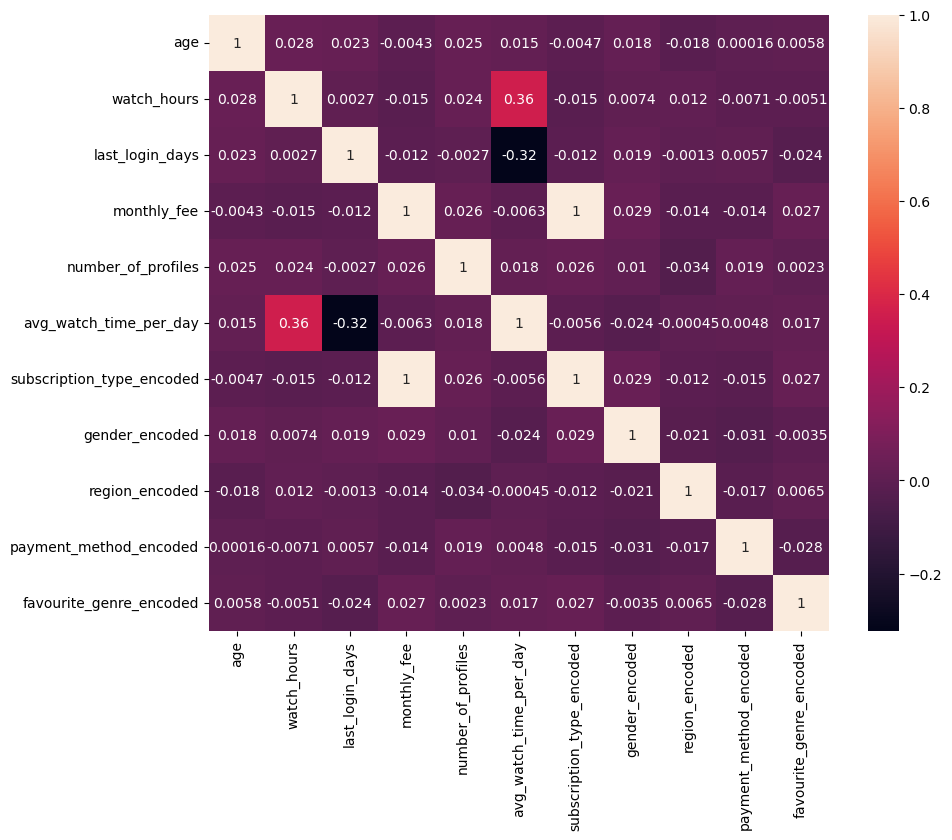

In [39]:
plt.figure(figsize=(10,8))
sns.heatmap(X_train.corr(),annot=True)

In [41]:
import lightgbm as lgb

In [43]:
model=lgb.LGBMClassifier()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)

[LightGBM] [Info] Number of positive: 1887, number of negative: 1863
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000186 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 659
[LightGBM] [Info] Number of data points in the train set: 3750, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.503200 -> initscore=0.012800
[LightGBM] [Info] Start training from score 0.012800


In [57]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [61]:
print("Accuracy Score : " , accuracy_score(y_test,y_pred))
print("Confussion Matrix : \n" , confusion_matrix(y_test,y_pred))
print("Classification Report : " , classification_report(y_test,y_pred))

Accuracy Score :  0.9952
Confussion Matrix : 
 [[621   1]
 [  5 623]]
Classification Report :                precision    recall  f1-score   support

           0       0.99      1.00      1.00       622
           1       1.00      0.99      1.00       628

    accuracy                           1.00      1250
   macro avg       1.00      1.00      1.00      1250
weighted avg       1.00      1.00      1.00      1250



In [63]:
from xgboost import XGBRFClassifier

In [65]:
model2=XGBRFClassifier()
model2.fit(X_train,y_train)
y_pred2=model2.predict(X_test)
print("Accuracy Score : " , accuracy_score(y_test,y_pred2))
print("Confussion Matrix : \n" , confusion_matrix(y_test,y_pred2))
print("Classification Report : " , classification_report(y_test,y_pred2))

Accuracy Score :  0.9472
Confussion Matrix : 
 [[610  12]
 [ 54 574]]
Classification Report :                precision    recall  f1-score   support

           0       0.92      0.98      0.95       622
           1       0.98      0.91      0.95       628

    accuracy                           0.95      1250
   macro avg       0.95      0.95      0.95      1250
weighted avg       0.95      0.95      0.95      1250

